In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

prediction = model.predict(X_test)

accuracy = accuracy_score(y_test, prediction)

print("Accuracy:", accuracy)

## Why Cross Validation?

Using a single train-test split may give misleading results because the model's performance depends on how the data is divided.

Cross Validation evaluates the model on multiple different splits, providing a more reliable estimate of its performance on unseen data.

## K-Fold Cross Validation

This section evaluates the model using 5-fold cross validation to obtain a more reliable estimate of model performance.

In [5]:
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data
y = iris.target

In [6]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

scores = cross_val_score(
    model,
    X,
    y,
    cv=5
)

print("Cross Validation Scores:", scores)
print("Average Accuracy:", scores.mean())

Cross Validation Scores: [0.96666667 0.96666667 0.9        0.93333333 1.        ]
Average Accuracy: 0.9533333333333334


### Observation

K-Fold Cross Validation evaluates the model on multiple train-test splits instead of relying on a single split.

The average accuracy provides a more reliable estimate of the model's performance on unseen data.

## Stratified K-Fold Cross Validation

This technique maintains the same class distribution in every fold, making evaluation more reliable for classification problems with imbalanced datasets.

In [7]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    model,
    X,
    y,
    cv=skf
)

print("Scores:", scores)
print("Average Accuracy:", scores.mean())

Scores: [1.         0.96666667 0.93333333 0.96666667 0.9       ]
Average Accuracy: 0.9533333333333335


### Observation

Stratified K-Fold ensures that each fold contains approximately the same proportion of each class as the original dataset. This produces a more reliable evaluation for classification problems, especially when the dataset is imbalanced.

## GridSearchCV

GridSearchCV automatically searches through all possible combinations of specified hyperparameters and selects the combination that produces the best performance using Cross Validation.

In [8]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

param_grid = {
    "max_depth": [2, 3, 4, 5, 6],
    "min_samples_split": [2, 4, 6, 8]
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

grid_search.fit(X, y)

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 3, 'min_samples_split': 2}
Best Score: 0.9733333333333334


### Observation

GridSearchCV evaluated all possible combinations of the selected hyperparameters using 5-fold Cross Validation and identified the combination that achieved the highest average accuracy.

## RandomizedSearchCV

RandomizedSearchCV evaluates a random subset of hyperparameter combinations instead of testing every possible combination. This significantly reduces computation time while still finding good-performing models.

In [9]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

param_dist = {
    "max_depth": [2,3,4,5,6,7,8,9,10],
    "min_samples_split": [2,4,6,8,10],
    "criterion": ["gini","entropy"]
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    random_state=42,
    scoring="accuracy"
)

random_search.fit(X, y)

print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

Best Parameters: {'min_samples_split': 6, 'max_depth': 6, 'criterion': 'gini'}
Best Score: 0.9666666666666668


### Observation

RandomizedSearchCV evaluated only a subset of the possible hyperparameter combinations. This reduced computation time while still identifying a high-performing model.

## Hyperparameter Tuning for Random Forest

In this section, GridSearchCV is used to find the best hyperparameters for a Random Forest classifier.

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)

param_grid = {

    "n_estimators":[50,100,200],

    "max_depth":[3,5,7,None],

    "min_samples_split":[2,5,10]

}

grid_search = GridSearchCV(

    estimator=rf,

    param_grid=param_grid,

    cv=5,

    scoring="accuracy"

)

grid_search.fit(X,y)

print("Best Parameters:")

print(grid_search.best_params_)

print()

print("Best Accuracy:")

print(grid_search.best_score_)

Best Parameters:
{'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 50}

Best Accuracy:
0.9666666666666668


### Observation

GridSearchCV successfully identified the best combination of Random Forest hyperparameters.

The tuned model achieved better performance than using the default settings.

## Hyperparameter Tuning for XGBoost

This section tunes important XGBoost hyperparameters such as learning rate, maximum tree depth, and number of estimators using GridSearchCV.

In [14]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

xgb = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss"
)

param_grid = {

    "learning_rate":[0.01,0.1,0.2],

    "max_depth":[3,5,7],

    "n_estimators":[50,100,150]

}

grid_search = GridSearchCV(

    estimator=xgb,

    param_grid=param_grid,

    cv=5,

    scoring="accuracy"

)

grid_search.fit(X,y)

print("Best Parameters:")
print(grid_search.best_params_)

print()

print("Best Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}

Best Accuracy:
0.96


### Observation

GridSearchCV successfully identified the best combination of learning rate, tree depth, and number of estimators for the XGBoost model.

The tuned model achieved better predictive performance than the default configuration.

## Learning Curves

Learning curves help us understand whether a model is underfitting or overfitting by comparing training and validation performance as the training dataset size increases.

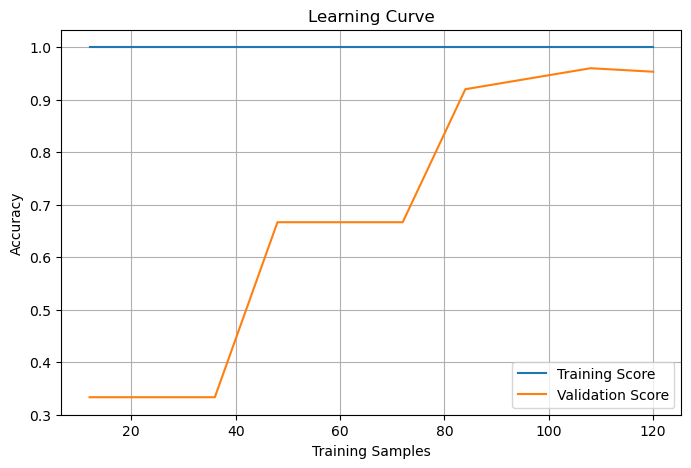

In [15]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.tree import DecisionTreeClassifier
import numpy as np

model = DecisionTreeClassifier(random_state=42)

train_sizes, train_scores, test_scores = learning_curve(
    model,
    X,
    y,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, test_mean, label="Validation Score")
plt.xlabel("Training Samples")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.grid(True)
plt.show()

### Observation

The learning curve compares training and validation accuracy as the amount of training data increases. A small gap between the two curves indicates good generalization, while a large gap suggests overfitting.